In [32]:
#Import dependencies
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from pmdarima.arima import ndiffs, nsdiffs
from pmdarima.model_selection import cross_val_score, RollingForecastCV
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from joblib import Parallel, delayed

In [33]:
#Fetch data
LAT, LON = 56.1629, 10.2039  # Aarhus
START, END = "2025-04-18", "2026-04-18"

# ── 1. Historical air quality (NO2, O3) ──────────────────────────────────────
print("Fetching air quality...")
aq = requests.get(
    "https://air-quality-api.open-meteo.com/v1/air-quality",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "nitrogen_dioxide,ozone,pm10,pm2_5",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

aq_df = pd.DataFrame({
    "Recorded": pd.to_datetime(aq["hourly"]["time"]),
    "NO2":      aq["hourly"]["nitrogen_dioxide"],
    "O3":       aq["hourly"]["ozone"],
    "PM10":     aq["hourly"]["pm10"],
    "PM2.5":    aq["hourly"]["pm2_5"],
})

# ── 2. Historical weather (wind, rain, temp, radiation) ──────────────────────
print("Fetching weather...")
wx = requests.get(
    "https://archive-api.open-meteo.com/v1/archive",
    params={
        "latitude": LAT,
        "longitude": LON,
        "hourly": "wind_speed_10m,temperature_2m,shortwave_radiation,relative_humidity_2m",
        "wind_speed_unit": "ms",
        "start_date": START,
        "end_date": END,
        "timezone": "Europe/Copenhagen"
    }
).json()

wx_df = pd.DataFrame({
    "Recorded":           pd.to_datetime(wx["hourly"]["time"]),
    "wind_speed":         wx["hourly"]["wind_speed_10m"],
    "temperature":        wx["hourly"]["temperature_2m"],
    "solar_radiation":    wx["hourly"]["shortwave_radiation"],
    "humidity":           wx["hourly"]["relative_humidity_2m"],

})

# ── 3. Merge and save ─────────────────────────────────────────────────────────
print("Merging...")
df = aq_df.merge(wx_df, on="Recorded", how="inner")
df = df.sort_values("Recorded").reset_index(drop=True)

print(f"\nFinal shape: {df.shape}")
print(df.head())
print(f"\nDate range: {df.Recorded.min()} → {df.Recorded.max()}")
print(f"Missing values:\n{df.isnull().sum()}")


Fetching air quality...
Fetching weather...
Merging...

Final shape: (8784, 9)
             Recorded  NO2    O3  PM10  PM2.5  wind_speed  temperature  \
0 2025-04-18 00:00:00  3.4  90.0   3.8    2.9        4.52          8.3   
1 2025-04-18 01:00:00  3.1  91.0   3.2    2.6        4.51          7.9   
2 2025-04-18 02:00:00  2.5  95.0   3.0    2.1        4.40          7.8   
3 2025-04-18 03:00:00  2.7  92.0   3.1    2.0        4.44          7.8   
4 2025-04-18 04:00:00  2.6  87.0   3.4    2.6        4.70          7.8   

   solar_radiation  humidity  
0              0.0        86  
1              0.0        87  
2              0.0        86  
3              0.0        91  
4              0.0        89  

Date range: 2025-04-18 00:00:00 → 2026-04-18 23:00:00
Missing values:
Recorded           0
NO2                0
O3                 0
PM10               0
PM2.5              0
wind_speed         0
temperature        0
solar_radiation    0
humidity           0
dtype: int64


In [34]:
# Setup
df["Recorded"] = pd.to_datetime(df["Recorded"])
df = df.set_index('Recorded')


target_col = 'NO2'
m = 24  # seasonal period (hourly data)

y = df[target_col].values
X = df[["wind_speed", "temperature", "solar_radiation", "humidity"]].values

# train/test split — hold out last 4 days (96 hours)
holdout = 96
y_train, y_test = y[:-holdout], y[-holdout:]
X_train, X_test = X[:-holdout], X[-holdout:]

In [35]:
#Scale exogenous features:

# Create scaler
X_scaler = StandardScaler()

# Fit on training data only
X_train_scaled = X_scaler.fit_transform(X_train)


In [36]:
# Determine d and D
d = ndiffs(y_train, test='kpss')
D = nsdiffs(y_train, m=m, test='ch')
print(f"d={d}, D={D}")

d=1, D=1


In [37]:
def full_diff(arr, d, D, m):
    # seasonal differencing first
    if arr.ndim == 1:
        for _ in range(D):
            arr = arr[m:] - arr[:-m]
        # then non-seasonal differencing
        for _ in range(d):
            arr = np.diff(arr)
    else:
        for _ in range(D):
            arr = arr[m:] - arr[:-m]
        for _ in range(d):
            arr = np.diff(arr, axis=0)
    return arr

y_train_diff = full_diff(y_train, d=d, D=1, m=24)
X_train_diff = full_diff(X_train_scaled, d=d, D=1, m=24)

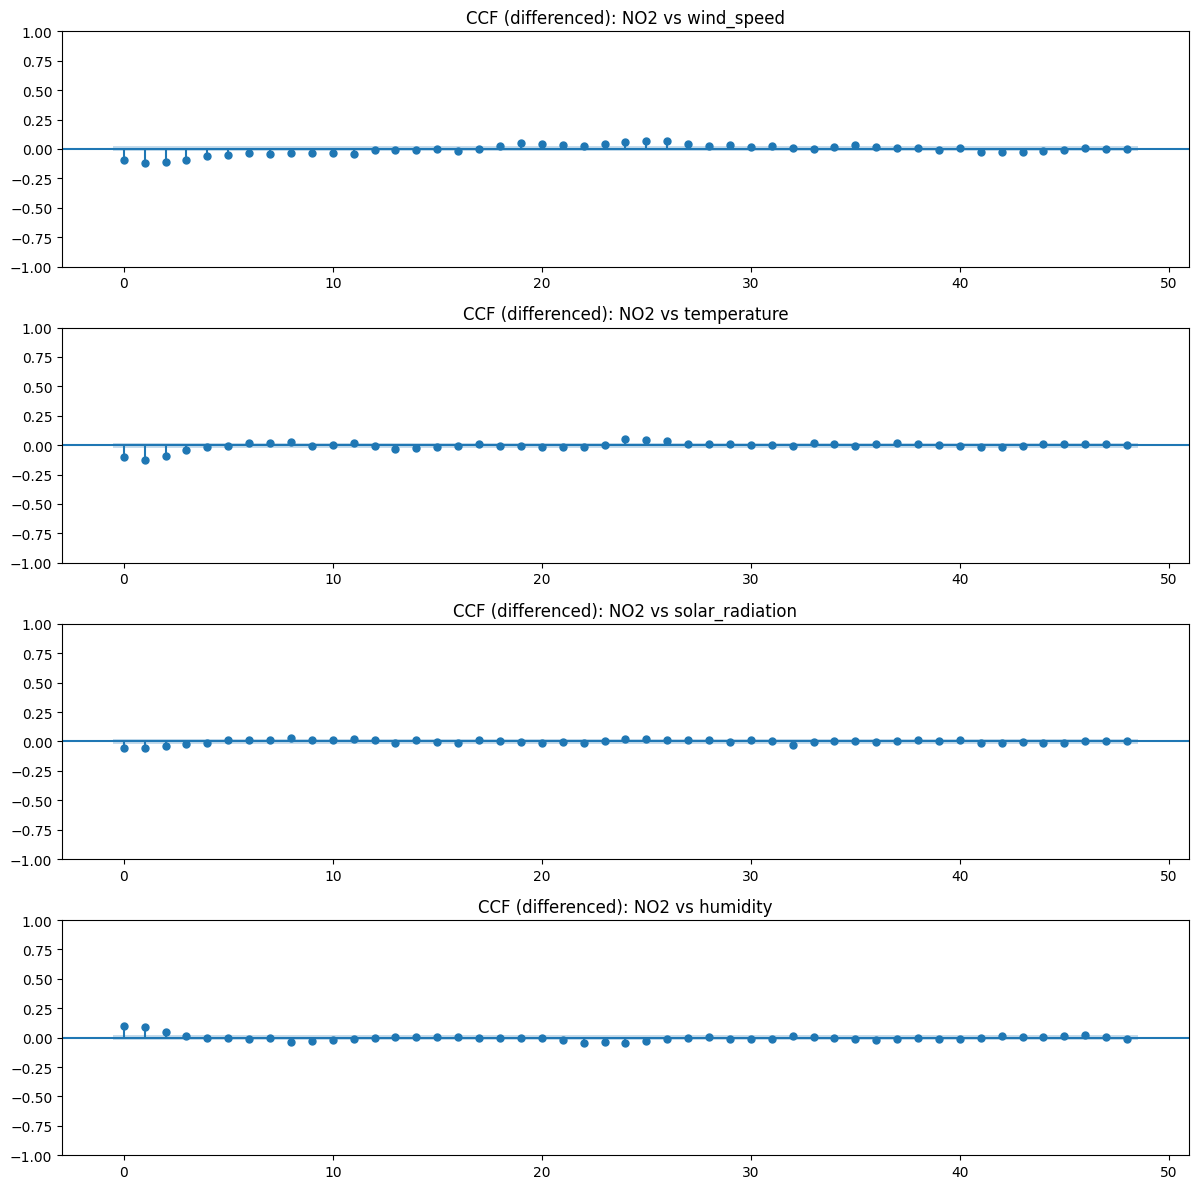

In [38]:
#plot
feature_cols = ["wind_speed", "temperature", "solar_radiation", "humidity"]
target_col = "NO2"

fig, axes = plt.subplots(len(feature_cols), 1, figsize=(12, 3 * len(feature_cols)))

for i, col in enumerate(feature_cols):
    plot_ccf(y_train_diff, X_train_diff[:, i], lags=48, ax=axes[i], negative_lags=False, alpha = 0.05)
    axes[i].set_title(f'CCF (differenced): {target_col} vs {col}')

plt.tight_layout()
plt.show()